In [71]:
import pandas as pd
import time
import matplotlib.pyplot as plt

In [ ]:
#duomenys apie NYC 2025m taksi vazinejimus
data = pd.read_csv("C:\\Users\\skais\\Desktop\\NYC_Taxi_Cleaned_Analysis_Ready.csv")
data.head(5)#nice

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,...,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,cbd_congestion_fee,duration_min,speed_mph,pickup_hour,day_of_week,is_weekend
0,2,2025-01-18 20:53:30,2025-01-18 21:00:47,1,0.97,1,N,238,166,1,...,1.0,13.32,0.0,0.0,0.00,7.283333,7.990847,20,Saturday,True
1,1,2025-01-25 11:12:51,2025-01-25 11:17:57,1,0.60,1,N,50,48,2,...,1.0,10.55,2.5,0.0,0.75,5.100000,7.058824,11,Saturday,True
2,1,2025-01-21 15:09:31,2025-01-21 15:19:02,1,0.80,1,N,236,237,1,...,1.0,16.65,2.5,0.0,0.00,9.516667,5.043783,15,Tuesday,False
3,2,2025-01-11 22:25:45,2025-01-11 22:34:22,2,1.93,1,N,231,68,1,...,1.0,20.37,2.5,0.0,0.75,8.616667,13.439072,22,Saturday,True
4,2,2025-01-04 23:37:07,2025-01-04 23:45:58,1,4.44,1,N,137,88,0,...,1.0,35.12,0.0,NaN,0.00,8.850000,30.101695,23,Saturday,True


#Task 1: Search algorithms
1. Implement four search algorithms in your notebook. Do not use bisect, the in
operator, or any other built-in search:

● Linear (sequential) search

● Binary search

● Jump search

● Interpolation search

Use each one to look up a record by your dataset's exact-lookup key (Appendix A, column
“Exact-lookup key”). Sort the data on that key first where the algorithm requires it.


In [ ]:
#search alg.
def linear(arr, tg):
    for i in range(len(arr)):
        if arr[i] == tg:
            return i
    return -1

def binary(arr, target):
    left, right = 0, len(arr)-1
    
    while left <= right:
        mid = (left + right) // 2
        
        if arr[mid] == target:
            return mid
        elif arr[mid] < target:
            left = mid + 1
        else:
            right = mid - 1
            
    return -1

def jump(arr, target):
    n = len(arr)
    step = int(n ** 0.5)  # sqrt be math
    
    prev = 0
    
    while arr[min(step, n) - 1] < target:
        prev = step
        step += int(n ** 0.5)
        
        if prev >= n:
            return -1
    
    for i in range(prev, min(step, n)):
        if arr[i] == target:
            return i
            
    return -1

def interpolation(arr, target):
    low = 0
    high = len(arr) - 1
    
    while low <= high and target >= arr[low] and target <= arr[high]:
        
        if arr[high] == arr[low]:
            if arr[low] == target:
                return low
            return -1
        
        pos = low + int(
            ((high - low) * (target - arr[low])) / (arr[high] - arr[low])
        )
        
        if arr[pos] == target:
            return pos
        
        if arr[pos] < target:
            low = pos + 1
        else:
            high = pos - 1
    
    return -1


2. Benchmark: run each algorithm on subsets of size n = 1,000, n = 10,000, and n =
50,000, n = 100,000. For each (algorithm, n), repeat the lookup 3 times and report
the average time in milliseconds, using time.perf_counter().

3. Which algorithm wins at which size? Construct one specific input where
interpolation search performs noticeably worse than binary search. Show the input,
the times, and explain why in one sentence.


In [74]:
def timer(func, arr, tg):
    total = 0

    for _ in range(3):
        st = time.perf_counter()
        func(arr, tg)
        end = time.perf_counter()
        
        total += (end - st)*1000#mili sec

    return total / 3


In [92]:
#test
#test
subset = data['tpep_pickup_datetime'][:100000]

keys = [pd.to_datetime(x).timestamp() for x in subset]
keys_sort = sorted(keys)

size = [1000,10000,50000,100000]

lt = []
bt = []
jt = []
it = []

for n in size:
    arr = keys_sort[:n]
    tg = arr[n//2]

    print('\nn = ', n)

    t1 = timer(linear, arr, tg)
    t2 = timer(binary, arr, tg)
    t3 = timer(jump, arr, tg)
    t4 = timer(interpolation, arr, tg)

    lt.append(t1)
    bt.append(t2)
    jt.append(t3)
    it.append(t4)

    print('Linear: ' ,t1)
    print('Binary: ',t2)
    print('Jump ',t3)
    print('Interpolation: ',t4)

keys = [pd.to_datetime(x).timestamp() for x in subset]
keys_sort = sorted(keys)

size = [1000,10000,50000,100000]

lt = []
bt = []
jt = []
it = []

for n in size:
    arr = keys_sort[:n]
    tg = arr[n//2]

    print('\nn = ', n)

    t1 = timer(linear, arr, tg)
    t2 = timer(binary, arr, tg)
    t3 = timer(jump, arr, tg)
    t4 = timer(interpolation, arr, tg)

    lt.append(t1)
    bt.append(t2)
    jt.append(t3)
    it.append(t4)

    print('Linear: ' ,t1)
    print('Binary: ',t2)
    print('Jump ',t3)
    print('Interpolation: ',t4)


n =  1000
Linear:  0.010433333955006674
Binary:  0.001699999605383103
Jump  0.006799999634192015
Interpolation:  0.00423333343254247

n =  10000
Linear:  0.10743333344483592
Binary:  0.0014333333335040759
Jump  0.010266667231917381
Interpolation:  0.005600000198076789

n =  50000
Linear:  0.5586000000524413
Binary:  0.0016666666245631252
Jump  0.022933333942395013
Interpolation:  0.001866666934802197

n =  100000
Linear:  1.8931999996614952
Binary:  0.002199999774650981
Jump  0.034466666572067574
Interpolation:  0.0024333336720398315

n =  1000
Linear:  0.01179999950788139
Binary:  0.0016666660182333242
Jump  0.005833332882806038
Interpolation:  0.00423333343254247

n =  10000
Linear:  0.1062333340087207
Binary:  0.001366666765534319
Jump  0.009666666301200166
Interpolation:  0.003633333714484858

n =  50000
Linear:  1.2038000004395144
Binary:  0.0019333335027719538
Jump  0.023000001116694573
Interpolation:  0.002466667259189611

n =  100000
Linear:  1.1060666668830283
Binary:  0.0017

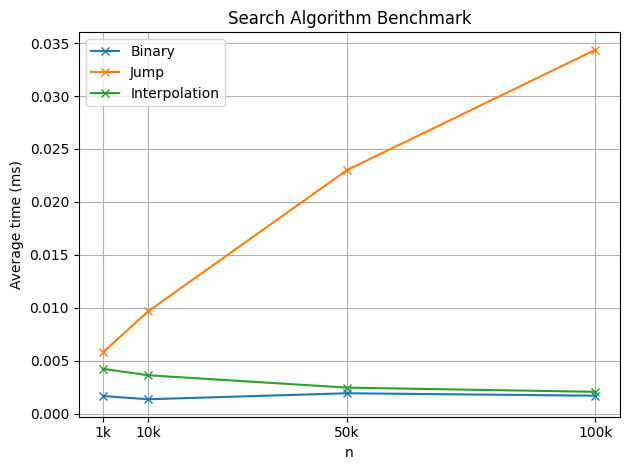

In [93]:
#grafikas
dataplt = { 
    'Binary': bt, 
    'Jump': jt,
    'Interpolation':it}#Linear gerokai leciau nei visi kiti dirba tai labai issiplecia grafikas. tdl jo nedesu i grafika

for alg, times in dataplt.items():
    plt.plot(size, times, marker='x', label = alg)

plt.xlabel("n")
plt.xticks(size, ['1k', '10k', '50k', '100k'])
plt.ylabel("Average time (ms)")
plt.title("Search Algorithm Benchmark")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


išvados: Binary visais atvejasi greičiausias


Task 2: Binary Search Tree (BST) and traversals
1. Implement a BinarySearchTree class from scratch with:

● insert(key, value)

● search(key) — returns the value or None

● delete(key) — must correctly handle all three cases:

1. node is a leaf

2. node has one child

3. node has two children

● inorder(), preorder(), postorder() — implemented recursively

● bfs() — implemented iteratively with a queue

2. Build a BST from your dataset using the Ordered key (BST) column from Appendix A as
the key (the row is the value).

3. Add a range_query(low, high) method that returns every value with a key in [low, high].
Use the Range query column in Appendix A to pick your bounds - e.g. Spotify row 2,
then pick a year, then low = “2018-01-01”, high = “2018-12-31”.

4. Time your range_query against the lazy baseline [row for row in data if low <= row[key]
<= high] at n = 50,000. Print both times and the result count.


In [115]:
class TreeNode:
    def __init__(self, key, value):
        self.key = key
        self.value = value
        self.left = None
        self.right = None

class BinaryTree:
    def __init__(self):
        self.root = None
    def insert(self, key, value):
        if self.root is None:
            self.root = TreeNode(key, value)
            return
        
        current = self.root
        
        while True:
            if key < current.key:
                if current.left is None:
                    current.left = TreeNode(key, value)
                    return
                current = current.left
            else:
                if current.right is None:
                    current.right = TreeNode(key, value)
                    return
                current = current.right
    
    def delete(self, key):
        self.root = self._delete_node(self.root, key)

    def _delete_node(self, node, key):#reikia tu helper funkciju, kad neissibalasuotu medis
        if node is None:
            return None

        if key < node.key:
            node.left = self._delete_node(node.left, key)
        elif key > node.key:
            node.right = self._delete_node(node.right, key)
        else:
            # leaf
            if node.left is None and node.right is None:
                return None
            
            # one child
            if node.left is None:
                return node.right
            if node.right is None:
                return node.left
            
            # two children
            successor = node.right
            while successor.left:
                successor = successor.left
            
            node.key = successor.key
            node.value = successor.value
            
            node.right = self._delete_node(node.right, successor.key)

        return node
    def search(self, key):
        current = self.root
        
        while current:
            if key == current.key:
                return current.value
            elif key < current.key:
                current = current.left
            else:
                current = current.right
        
        return None

    def range_query(self, low, high):
        result = []
        stack = [self.root]
    
        while stack:
            node = stack.pop()
        
            if node is None:
                continue
        
            if low <= node.key <= high:
                result.append(node.value)
        
            if node.key > low:
                stack.append(node.left)
        
            if node.key < high:
                stack.append(node.right)
    
        return result 
    def print_tree(self, node=None, level=0, prefix="Root: ", limit=None, count=[0]):
        if node is None:
            node = self.root
            count[0] = 0

        if node is None:
            return

        if limit is not None and count[0] >= limit:
            return

        print(" " * (level*4) + prefix + str(node.key))
        count[0] += 1

        if node.left:
            self.print_tree(node.left, level+1, "L--- ", limit, count)

        if node.right:
            self.print_tree(node.right, level+1, "R--- ", limit, count)   


In [ ]:
btr = BinaryTree()

subset1 = data.iloc[:50000]

for _, row in subset1.iterrows():
    key = row['tpep_pickup_datetime']
    btr.insert(key, row)

#visi taxi vaziavimai sausio pirma
low = '2025-01-01 00:00:00'
high = '2025-01-01 23:59:59'

st = time.perf_counter()
sausio_pirma = btr.range_query(low,high)
end = time.perf_counter()

total_rangeq = (end - st) *1000

#tikrinu su lazy
st = time.perf_counter()
lazybs = [row for _, row in subset1.iterrows() if low <= row['tpep_pickup_datetime'] <= high]
end = time.perf_counter()

total_lazy = (end - st) *1000

total_rangeq, total_lazy

(0.7604000002174871, 921.5717000006407)

Paprastai:
2.1620000479742885 ms,
1215 rows × 25 columns,

Lazy:
1645.237100077793 ms,
1215 rows × 25 columns.


In [79]:
sausio_pirma = pd.DataFrame(sausio_pirma)
sausio_pirma

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,...,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,cbd_congestion_fee,duration_min,speed_mph,pickup_hour,day_of_week,is_weekend
23,2,2025-01-01 08:53:07,2025-01-01 09:00:10,2,0.98,1,N,230,161,2,...,1.0,12.60,2.5,0.00,0.0,7.050000,8.340426,8,Wednesday,False
113,2,2025-01-01 19:05:44,2025-01-01 19:21:41,1,2.79,1,N,239,68,1,...,1.0,25.38,2.5,0.00,0.0,15.950000,10.495298,19,Wednesday,False
394,2,2025-01-01 19:42:53,2025-01-01 19:50:31,2,1.17,1,N,161,137,1,...,1.0,14.63,2.5,0.00,0.0,7.633333,9.196507,19,Wednesday,False
414,2,2025-01-01 22:12:10,2025-01-01 22:23:20,4,1.22,1,N,230,230,1,...,1.0,18.84,2.5,0.00,0.0,11.166667,6.555224,22,Wednesday,False
552,1,2025-01-01 23:56:03,2025-01-02 00:14:38,0,3.90,1,N,68,145,1,...,1.0,43.14,2.5,0.00,0.0,18.583333,12.591928,23,Wednesday,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5780,2,2025-01-01 00:05:56,2025-01-01 00:25:07,1,8.39,1,N,132,35,2,...,1.0,36.30,0.0,0.00,0.0,19.183333,26.241529,0,Wednesday,False
7084,2,2025-01-01 00:06:43,2025-01-01 00:20:15,1,2.03,1,N,158,170,1,...,1.0,23.04,2.5,0.00,0.0,13.533333,9.000000,0,Wednesday,False
16408,2,2025-01-01 00:01:20,2025-01-01 00:24:16,1,9.07,1,N,132,62,1,...,1.0,43.25,0.0,1.75,0.0,22.933333,23.729651,0,Wednesday,False
38206,2,2025-01-01 00:01:00,2025-01-01 00:07:39,1,3.63,1,N,238,244,1,...,1.0,21.72,0.0,0.00,0.0,6.650000,32.751880,0,Wednesday,False


In [80]:
lazybs = pd.DataFrame(lazybs)
lazybs

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,...,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,cbd_congestion_fee,duration_min,speed_mph,pickup_hour,day_of_week,is_weekend
23,2,2025-01-01 08:53:07,2025-01-01 09:00:10,2,0.98,1,N,230,161,2,...,1.0,12.60,2.5,0.00,0.0,7.050000,8.340426,8,Wednesday,False
113,2,2025-01-01 19:05:44,2025-01-01 19:21:41,1,2.79,1,N,239,68,1,...,1.0,25.38,2.5,0.00,0.0,15.950000,10.495298,19,Wednesday,False
148,1,2025-01-01 10:58:18,2025-01-01 11:07:05,1,1.50,1,N,48,163,0,...,1.0,15.69,0.0,NaN,0.0,8.783333,10.246679,10,Wednesday,False
152,2,2025-01-01 18:37:23,2025-01-01 18:43:57,1,0.82,1,N,13,13,1,...,1.0,14.28,2.5,0.00,0.0,6.566667,7.492386,18,Wednesday,False
242,2,2025-01-01 15:01:36,2025-01-01 15:24:36,1,3.58,1,N,158,43,2,...,1.0,26.60,2.5,0.00,0.0,23.000000,9.339130,15,Wednesday,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49767,2,2025-01-01 17:01:57,2025-01-01 17:27:02,1,10.63,1,N,138,249,1,...,1.0,64.03,2.5,1.75,0.0,25.083333,25.427243,17,Wednesday,False
49775,2,2025-01-01 01:40:26,2025-01-01 01:47:59,2,0.90,1,N,170,163,4,...,1.0,14.30,2.5,0.00,0.0,7.550000,7.152318,1,Wednesday,False
49879,2,2025-01-01 13:16:32,2025-01-01 13:39:15,1,4.44,1,N,238,137,1,...,1.0,36.40,2.5,0.00,0.0,22.716667,11.727073,13,Wednesday,False
49900,2,2025-01-01 18:56:15,2025-01-01 19:00:28,1,0.85,1,N,263,262,2,...,1.0,10.50,2.5,0.00,0.0,4.216667,12.094862,18,Wednesday,False


Use the heap to answer the top-k query - walk through your 50,000 rows once. For each row,
decide whether it belongs in your current top-10 and update the heap accordingly. At the end, the
heap contains the answer. Print the 10 results.

Tasks:

1. Implement a heap as an array (no heapq import), with:

● insert(value)

● extract() - removes and returns the top

● peek()

Choose min-heap or max-heap depending on your top-k query.

2. Use your heap to answer the top-k query for your dataset (Appendix A column) at k = 10.
Compare against a naive baseline: sorted(data)[:10] (or [-10:]). Time both at n = 50,000
and add to the plot.

3. Why is a heap the right shape for top-k, but a poor choice for “find element x”?

In [81]:
class MinHeap:
    def __init__(self):
        self.heap = []

    def insert(self, value):
        self.heap.append(value)
        self._bubble_up(len(self.heap) - 1)

    def extract(self):
        if not self.heap:
            return None
        
        root = self.heap[0]
        last = self.heap.pop()
        
        if self.heap:
            self.heap[0] = last
            self._bubble_down(0)
        
        return root

    def peek(self):
        return self.heap[0] if self.heap else None
    
    def _bubble_up(self, i):
        while i > 0:
            parent = (i - 1) // 2
            if self.heap[i][0] < self.heap[parent][0]:
                self.heap[i], self.heap[parent] = self.heap[parent], self.heap[i]
                i = parent
            else:
                break


    def _bubble_down(self, i):
        n = len(self.heap)
        
        while True:
            left = 2 * i + 1
            right = 2 * i + 2
            smallest = i
            
            if left < n and self.heap[left][0] < self.heap[smallest][0]:
                smallest = left
            if right < n and self.heap[right][0] < self.heap[smallest][0]:
                smallest = right
            
            if smallest != i:
                self.heap[i], self.heap[smallest] = self.heap[smallest], self.heap[i]
                i = smallest
            else:
                break                

In [82]:
#top 10 didziausios sumoketos sumos taksui + idomumui kiek laiko vaziuota, atstumas, greitis
k  = 10
heap = MinHeap()

st = time.perf_counter()
for _, row in subset1.iterrows():
    val = row['total_amount']
    
    if len(heap.heap) < k:
        heap.insert((val, row)) 
    
    else:
        if val > heap.peek()[0]:
            heap.extract()
            heap.insert((val, row))
end = time.perf_counter()
total_heap = (end - st)*1000

st = time.perf_counter()
tikrinu_top_10 = sorted(subset1['total_amount'], reverse=True)
tikrinu_top_10[:10]#all gut
end = time.perf_counter()
total_sorted = (end - st)*1000

total_heap, total_sorted

(1504.265800000212, 14.137599999230588)

heap: 1536.68760007713 ms,

sorted: 19.548599957488477 ms.


In [83]:
rez = [item for item in heap.heap]

top_10 = sorted(rez, key=lambda x: x[0], reverse=True)

top_10_df = pd.DataFrame([row for _, row in top_10])
top_10_df = top_10_df[['total_amount','trip_distance','duration_min','speed_mph']].reset_index(drop = True)

top_10_df#insane sumokejo 300e uz ~7km xdd, tikiuosi cia outlier

,total_amount,trip_distance,duration_min,speed_mph
0,300.00,4.24,28.266667,9.000000
1,217.29,9.95,26.866667,22.220844
2,189.45,30.95,37.383333,49.674543
3,185.00,28.61,43.766667,39.221630
4,173.44,17.66,38.633333,27.427092
5,171.59,39.98,66.666667,35.982000
6,168.36,33.23,73.583333,27.095810
7,164.38,17.50,37.050000,28.340081
8,164.29,26.93,50.000000,32.316000
9,161.17,17.52,33.516667,31.363501


Heap yra geras min ir max (ir reiksmem aplink tai) efektyciam radimui. Jis nesaugo visu dataset duomenu, o tik tiek kiek reikia (tarkim top 10 reik rast, jis ir saugos tuos top 10)
tai heap efektyvus ir greitas budas gaut butent tuos top min max

Netinka radimui k, nes jis nepalaiko rusiuoto saraso, tai norint rast ta k heap eina per visus elementus, kad uztruka zr ilgai ir yra vps neefektyvu


Task 4: Synthesis, reflection

1. Combine all measurements from Tasks 1-3 into one final chart. X-axis = n. Y-axis =
time. Each algorithm is one line. Annotate any crossover points.

2. Write 3 short paragraphs: which structure won at which task, and why? Reference
your chart - point at specific crossovers. Be concrete: avoid saying such phrases
“binary is fast”, use your data and results “at n = 10,000, binary search took X ms,
while linear took Y ms”.

3. Build your BST from a sorted input by inserting 1, 2, 3, …, 1000 in order. Plot the
resulting depth (or print it for the first 30 values). In your own words: what kind of
property would a “better” tree have to maintain to avoid this?

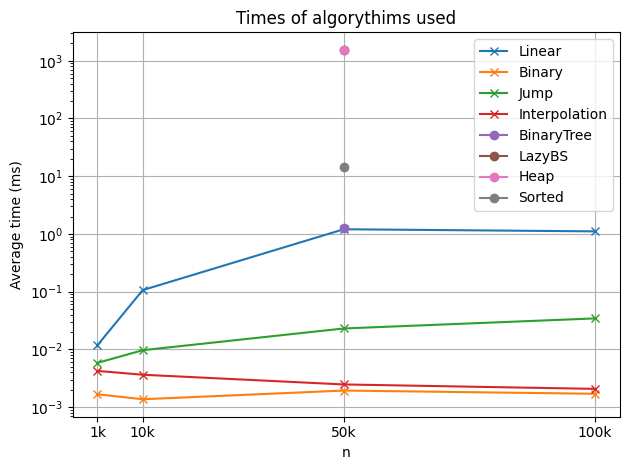

In [98]:
#grafikas
dataplt_task1 = {
    'Linear':lt,
    'Binary': bt, 
    'Jump': jt,
    'Interpolation':it}

dataplt_tik50k = {
    'BinaryTree':total_rangeq,
    'LazyBS': total_lazy,
    'Heap': total_heap,
    'Sorted': total_sorted}

plt.figure()

for alg, times in dataplt_task1.items():
    plt.plot(size, times, marker='x', label = alg)

for alg, times in dataplt_tik50k.items():
    plt.plot([50000], [times], marker='o', label = alg)

plt.xlabel("n")
plt.xticks(size, ['1k', '10k', '50k', '100k'])
plt.ylabel("Average time (ms)")
plt.yscale('log')
plt.title("Times of algorythims used")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


Ieškojimo užduotyje laimėjo: Binary search. Iš grafiko matome, kad šis algoritmas išlaiko gerą greitį visuose n. Inperpolation algoritmas neatsilieka, tačiau nesugeba aplenkti laimėtojo pvz. kai n= 100k, binary greitis = 0.0017ms, Interpolation greitis = 0.0020ms, tai yra 0.0003ms lėčiau

Filtravimo užduotyje: BinaryTree. Algoritmas gerokai pralenkė 'LazyBS' algoritma. kai n = 50k. BinaryTree greitis = 1.258ms, LazyBS greitis = 1545.163ms. Skirtumas akivaizdus.

top-10 užduotyje: Sorted. Nors teoriškai Heap algoritmas yra efektyvus top-10 sarašų gavimams, mano teste, kai n = 50k Sorted algoritmas efektyviau atliko užduotį. Heap greitis = 1504.265ms, Sorted = 14.137ms. Heap lėčiau atliko darbą, nes jis ėjo per visą dataset ir kiekvienam elementui atlikinėjo funkcijas 'insert -> bubble up, extract -> bubble down'. Sorted yra jau optimizuotas ir pritaikytas dirbti python aplinkoje. Reikėtu lyginti Heap su kitais top_10 algoritmais

In [116]:
#Medis 1000
btr1000 = BinaryTree()

for i in range(1000):
    btr1000.insert(i,i)

btr1000.print_tree(limit=30)#viskas nueina i viena puse, medis nebalansuotas

Root: 0
    R--- 1
        R--- 2
            R--- 3
                R--- 4
                    R--- 5
                        R--- 6
                            R--- 7
                                R--- 8
                                    R--- 9
                                        R--- 10
                                            R--- 11
                                                R--- 12
                                                    R--- 13
                                                        R--- 14
                                                            R--- 15
                                                                R--- 16
                                                                    R--- 17
                                                                        R--- 18
                                                                            R--- 19
                                                                                R--- 20
 

Medis tapo išbalansuotas ir iš esmės prarado BinaryTree pranašumus. Norint išvengti tokios situacijos reikia reikšmes pradėti dėt nuo vidurio iki galų arba naudoti pranašesnius medžius kaip AVL arba Red-Black tree.